# Volatility Modelling with GARCH

## 1. Research Objective

We now look to model the rolling volatility which we have previously discussed using the Generalised Autoregressive Conditional Heteroskedasticity (GARCH) models. The objective is to fit a GARCH(1,1) model to SPY daily log returns, estimate conditional volatility, and generate volatility forecasts.

## 2. Import Libraries

In [1]:
import numpy as np
import pandas as pd

import yfinance as yf

import matplotlib.pyplot as plt

from arch import arch_model

## 3. Load Historical Data

In [2]:
spy = yf.download("SPY", start="2015-01-01", end="2026-01-01")

spy = spy[["Close"]].copy()

spy["Log_Return"] = np.log(spy["Close"] / spy["Close"].shift(1))

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,Log_Return
Ticker,SPY,
Date,,
2015-01-05,166.623398,-0.018224
2015-01-06,165.053879,-0.009464
2015-01-07,167.110733,0.012385
2015-01-08,170.076050,0.017589
2015-01-09,168.713150,-0.008046


## 4. Reviewing Volatility Clustering

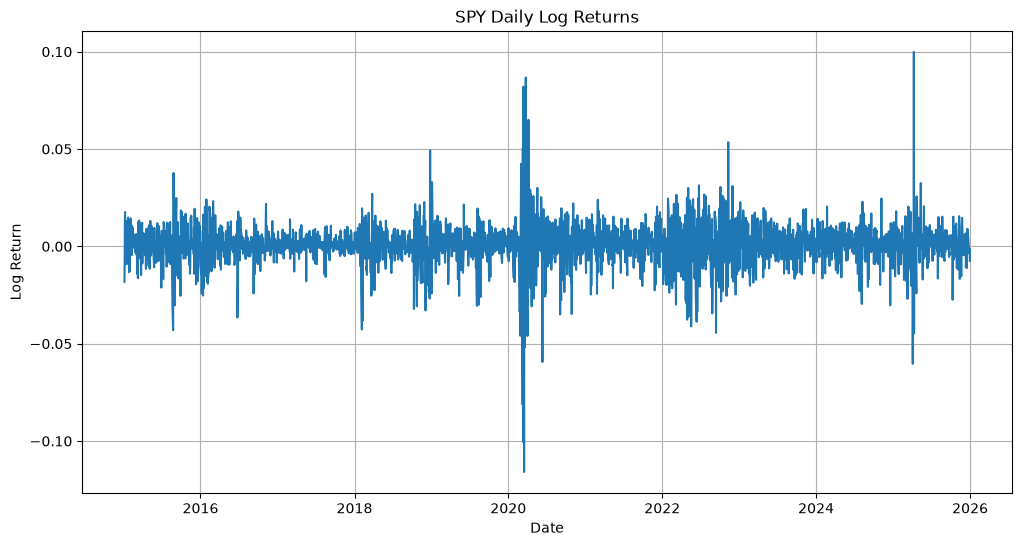

In [3]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, spy["Log_Return"])

plt.title("SPY Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()

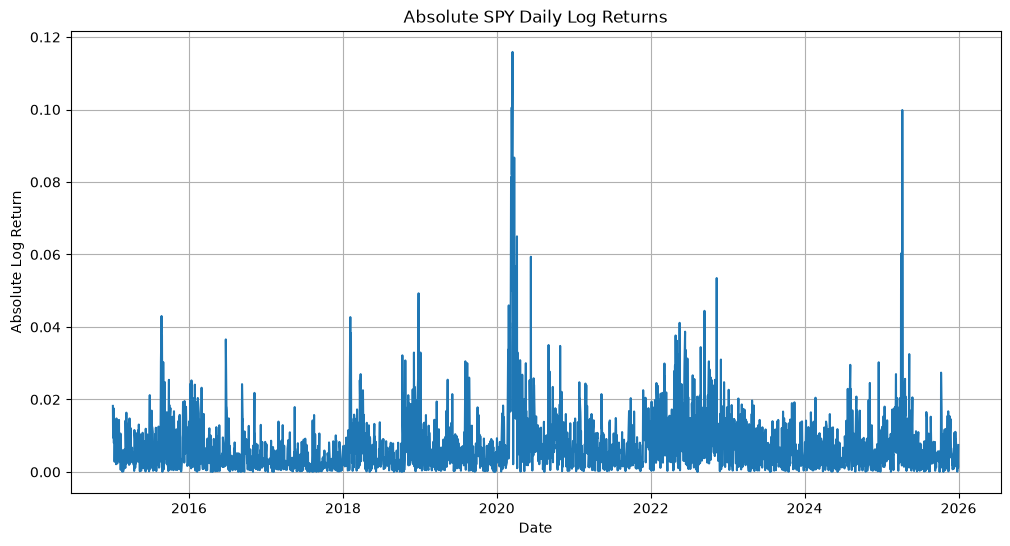

In [5]:
plt.figure(figsize=(12,6))

plt.plot(spy.index, np.abs(spy["Log_Return"]))

plt.title("Absolute SPY Daily Log Returns")
plt.xlabel("Date")
plt.ylabel("Absolute Log Return")

plt.grid(True)

plt.show()

We can quite clearly see the volatility clustering theory in these plots, so now we can begin to model this and evaluate the effectiveness of the model. 

## 5. Introduction to ARCH and GARCH

ARCH and GARCH models are extremely popular in volatility and risk modelling and we will begin to define the process. 

We start with the returns:

$$ r_t = \mu + \epsilon_t $$

Then the $ARCH(1)$ model is defined: 

$$ \sigma_t^2 = \omega + \alpha_1 \epsilon_{t-1}^2 $$

And the $GARCH(1,1)$ model as:

$$ \sigma_t^2 = \omega + \alpha \epsilon_{t-1}^2 + \beta \sigma_{t-1}^2 $$

where:

- $\sigma_t^2$ = conditional variance
- $\omega$ = long-run variance
- $\alpha$ = reaction to new information
- $\beta$ = persistence of volatility

In [6]:
garch = arch_model(
    spy["Log_Return"],
    vol="GARCH",
    p=1,
    q=1,
    mean="Constant"
)

garch_fit = garch.fit()

print(garch_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 169947984639.69025
Iteration:      2,   Func. Count:     20,   Neg. LLF: 7.499751330211873e+21
Iteration:      3,   Func. Count:     35,   Neg. LLF: 7.254574191917427e+23
Iteration:      4,   Func. Count:     50,   Neg. LLF: 52443831790557.78
Iteration:      5,   Func. Count:     64,   Neg. LLF: 1.2825528232862159e+26
Iteration:      6,   Func. Count:     79,   Neg. LLF: 4436188307110.878
Iteration:      7,   Func. Count:     90,   Neg. LLF: 8092873578697.127
Iteration:      8,   Func. Count:    105,   Neg. LLF: 8592955634207.776
Iteration:      9,   Func. Count:    117,   Neg. LLF: -6989.120347729294
Optimization terminated successfully    (Exit mode 0)
            Current function value: -6989.1203227354
            Iterations: 13
            Function evaluations: 117
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Results                      
Dep. Variable:             Log_Return   R-squared:

/opt/anaconda3/envs/quant-research/lib/python3.12/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001261. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)


Analysing the data, we firstly look at the estimates for our coefficients. 

$ \omega = 2.5233 $ x $ 10^{-6} $

$ \alpha = 0.200 $

$ \beta = 0.780 $

The $\alpha$ coefficient tells us that approximately $20%$ of today's variance is explained by the previous day's squared return, and our $\beta$ coefficient indicates that once volatility increases, it decays relatively slowly over time. This is precisely the volatility clustering we set out to find. This is also supported by $ \alpha + \beta = 0.98$. 

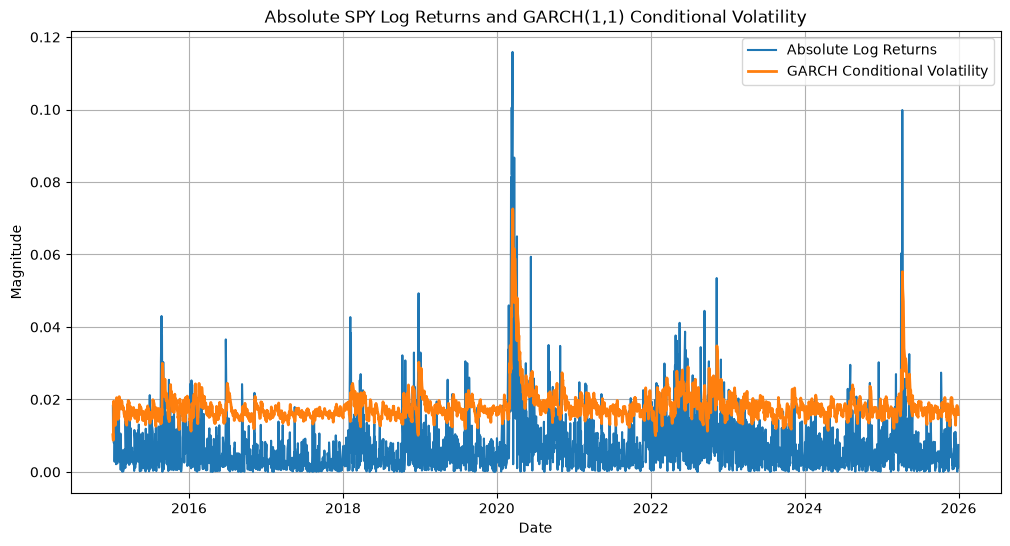

In [9]:
conditional_volatility = garch_fit.conditional_volatility

plt.figure(figsize=(12,6))

plt.plot(spy.index, np.abs(spy["Log_Return"]), label="Absolute Log Returns")
plt.plot(spy.index, conditional_volatility, linewidth=2, label="GARCH Conditional Volatility")

plt.title("Absolute SPY Log Returns and GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Magnitude")

plt.legend()
plt.grid(True)

plt.show()

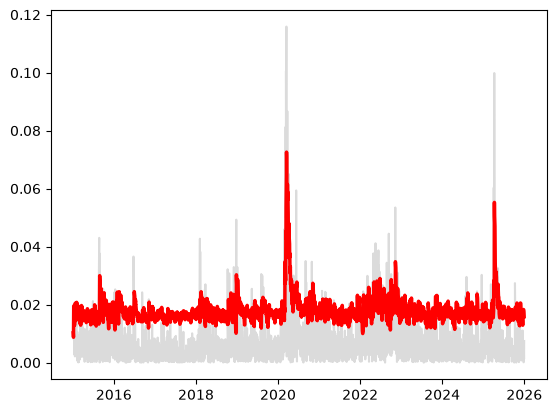

In [10]:
plt.plot(
    spy.index,
    np.abs(spy["Log_Return"]),
    color="lightgrey",
    alpha=0.8,
    label="Absolute Log Returns"
)

plt.plot(
    spy.index,
    conditional_volatility,
    color="red",
    linewidth=2.5,
    label="GARCH Conditional Volatility"
)

As we can see the GARCH model does a much better job than previous time-series models we have discussed.

## 6. Forecasting Future Volatility

Now we have estimated the conditional volatility throughout the historical data, we can now use the $GARCH(1,1)$ model to forecast future market volatility.

In [15]:
forecast = garch_fit.forecast(horizon=5)

forecast_variance = forecast.variance.iloc[-1]

forecast_volatility = np.sqrt(forecast_variance)

print(forecast_volatility)

h.1    0.014478
h.2    0.014421
h.3    0.014364
h.4    0.014308
h.5    0.014253
Name: 2025-12-31 00:00:00, dtype: float64


Now we will plot this to compare it to the previous 30 trading days. 

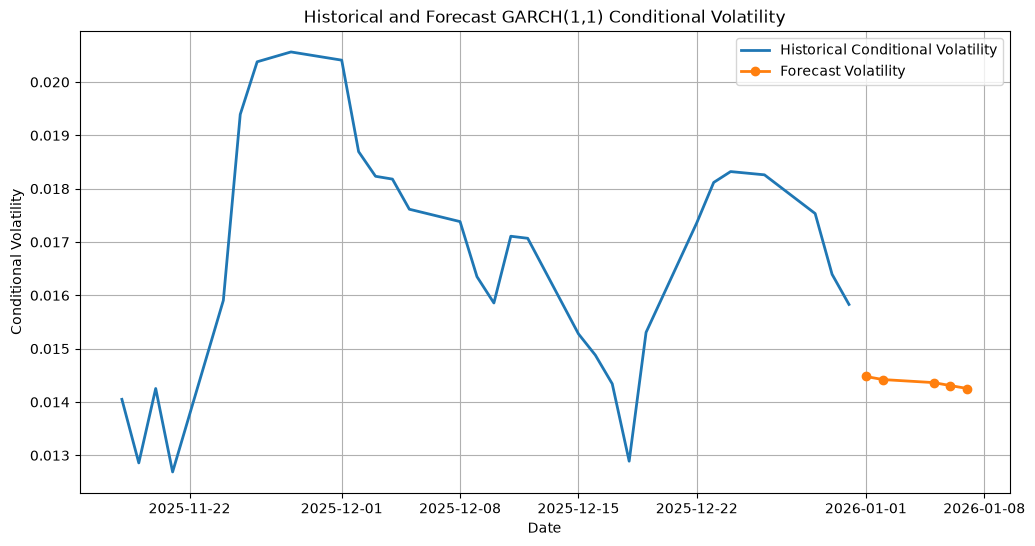

In [16]:
historical_volatility = garch_fit.conditional_volatility.iloc[-30:]

forecast_dates = pd.bdate_range(
    start=spy.index[-1] + pd.Timedelta(days=1),
    periods=5
)

plt.figure(figsize=(12,6))

plt.plot(
    historical_volatility.index,
    historical_volatility,
    linewidth=2,
    label="Historical Conditional Volatility"
)

plt.plot(
    forecast_dates,
    forecast_volatility.values,
    marker="o",
    linewidth=2,
    label="Forecast Volatility"
)

plt.title("Historical and Forecast GARCH(1,1) Conditional Volatility")
plt.xlabel("Date")
plt.ylabel("Conditional Volatility")

plt.legend()

plt.grid(True)

plt.show()

The $GARCH(1,1)$ forecasts a gradual decline in conditional volatility over the next five trading days, which is what we expect, despite its slope being slightly to flat.

## 7. Model Evaluation

The $GARCH(1,1)$ model successfully captured the volatility clustering observed in the SPY return series, and the estimated parameters were all statistically signficant, leading to the most notable finding:

$$ \alpha + \beta = 0.98 $$